# 1. Generación y "Hola Mundo" ArUco
El primer paso es entender que los marcadores pertenecen a diccionarios específicos (como el `DICT_4X4_50`).

Reto: Genera e imprime 4 marcadores diferentes. Crea un script en Python que los detecte en tiempo real y dibuje sus bordes y su ID único en pantalla.


<font color=#09FF >Por qué **importa**</font> : A diferencia de un objeto rojo, cada ArUco tiene una identidad propia. Esto te permitirá, en el futuro, distinguir entre el "Robot A", el "Obstáculo B" y la "Meta".

In [5]:
#Importar librerias
import cv2
import cv2.aruco as aruco
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



In [ ]:
#1. Definimos el diccionario que usaremos
aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
''' El nombre tecncio de  esta libreria indica:
4X4: Significa que el marcador está compuesto
por una cuadrícula de celdas (bits).

50: Indica que el diccionario contiene exactamente 50 marcadores
únicos, numerados del 0 al 49. 
'''

#2. Generar 4 marcadores de diferentes ID (0 al 3) de esos 50 de la biblioteca generada
for i  in range(4):
    #crear una imagen en blanco para el marcador
    #400x400 piceles, con un borde de 1 bit
    marker_img = aruco.generateImageMarker(aruco_dict,i,400)

    #Guardamos la imagen
    file_name = f"marker_id_{i}.png"
    cv2.imwrite(file_name,marker_img)
    print(f"Marcador guardado: {file_name}")
    '''
    Consejo de Visión: Al imprimir estos marcadores, asegúrate de que el borde
    blanco (zona de quietud) sea visible. Si los pegas en una base rígida,
    evitarás deformaciones que podrían engañar al algoritmo de detección.
    '''

Marcador guardado: marker_id_0.png
Marcador guardado: marker_id_1.png
Marcador guardado: marker_id_2.png
Marcador guardado: marker_id_3.png


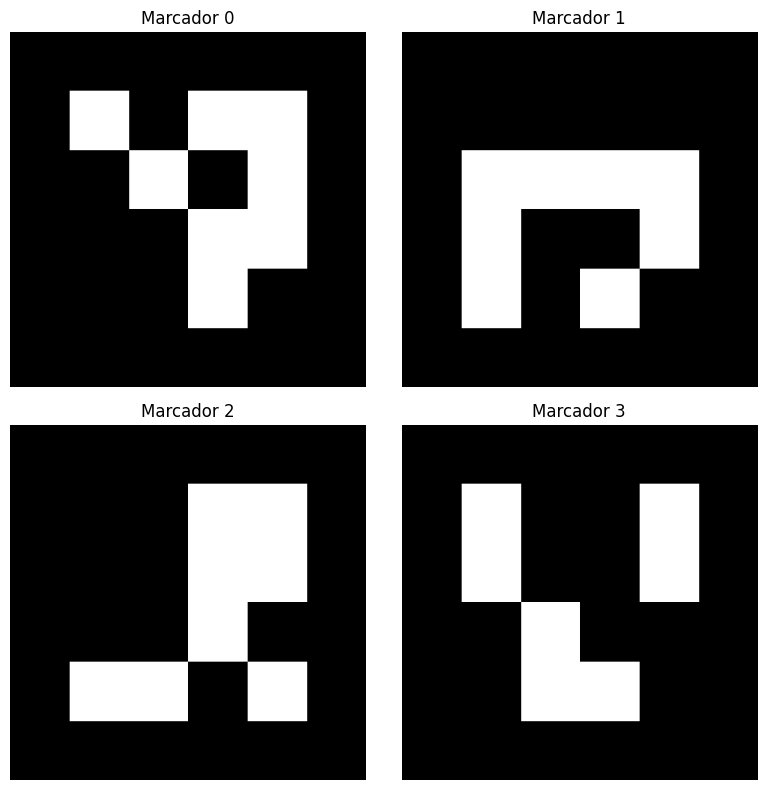

In [ ]:
# Lista con los nombres
imagenes = [
    "marker_id_0.png",
    "marker_id_1.png",
    "marker_id_2.png",
    "marker_id_3.png"
]

# Crear una cuadrícula de 2 filas y 2 columnas
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

# Iterar y mostrar cada imagen en su respectivo lugar
for i, nombre_archivo in enumerate(imagenes):
    # Cargar la imagen con PIL
    img = Image.open(nombre_archivo)
    
    # Determinar la posición en la cuadrícula (fila, columna)
    fila = i // 2
    columna = i % 2
    
    # Mostrar la imagen
    axs[fila, columna].imshow(img,cmap='gray')
    axs[fila, columna].set_title(f"Marcador {i}")
    axs[fila, columna].axis('off') # Ocultar los ejes numéricos

# Ajustar el espacio y mostrar la ventana
plt.tight_layout()
plt.show()


Ahora, este script activará la cámara, buscará los marcadores e identificará sus IDs únicos. A diferencia de tu segmentador de color rojo, aquí no buscamos "manchas", sino patrones binarios precisos.

# Codigo aplicado en la raspberry
```python
import camara
import cv2
import cv2.aruco as aruco

# Configuración del diccionario y parámetros de detección
aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
parameters = aruco.DetectorParameters()

# Crear detector
detector = aruco.ArucoDetector(aruco_dict, parameters)

# Inicializar cámara
cam = camara.init_cam()

if cam is None:
    exit()

print('Presiona q para salir...')

while True:

    # Capturar frame
    frame = cam.capture_array()

    # Rotar imagen
    frame = cv2.rotate(frame, cv2.ROTATE_180)

    # Convertir a escala de grises
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detectar marcadores
    corners, ids, rejected = detector.detectMarkers(gray)

    # Si se detectan marcadores
    if ids is not None:

        # Dibujar marcadores detectados
        aruco.drawDetectedMarkers(frame, corners, ids)

        # Mostrar IDs detectados
        for i in range(len(ids)):
            print(f"ID detectado: {ids[i][0]}")

    # Mostrar frame
    cv2.imshow('ArUco Hello World', frame)

    # Salir con la tecla q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Liberar recursos
cam.stop()
cv2.destroyAllWindows()
```

- Este método es extremadamente rápido de procesar , lo cual es vital para mantener el lazo de control PID que ya tienes implementado en tu robot.
- Al obtener los corners (esquinas), ya tenemos la base geométrica para calcular la orientación en 3D en el siguiente ejercicio.